<a href="https://colab.research.google.com/github/Raman-Dhillon/self-pruning-neural-network/blob/main/selfpruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [11]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Important: initialize around 0
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) * 0.1)

    def forward(self, x):
        # temperature scaling for sharp pruning
        gates = torch.sigmoid(10 * self.gate_scores)

        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def sparsity_loss(self):
        gates = torch.sigmoid(10 * self.gate_scores)
        return torch.mean(gates)

In [12]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def sparsity_loss(self):
        return (
            self.fc1.sparsity_loss() +
            self.fc2.sparsity_loss() +
            self.fc3.sparsity_loss()
        )

In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128)

In [14]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in testloader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    return 100 * correct / total


def calculate_sparsity(model, threshold=0.2):
    total, zero = 0, 0

    for layer in [model.fc1, model.fc2, model.fc3]:
        gates = torch.sigmoid(10 * layer.gate_scores)
        total += gates.numel()
        zero += (gates < threshold).sum().item()

    return 100 * zero / total

In [15]:
def train_model(lambda_max, epochs=15):
    model = Net().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()

        # Gradually increase lambda
        lambda_sparse = lambda_max * (epoch / epochs)

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()

            out = model(x)
            ce_loss = criterion(out, y)
            sp_loss = model.sparsity_loss()

            loss = ce_loss + lambda_sparse * sp_loss

            loss.backward()
            optimizer.step()

        print(f"Epoch {epoch+1} | λ={lambda_sparse:.4f}")

    acc = evaluate(model)
    sparsity = calculate_sparsity(model)

    return model, acc, sparsity

In [16]:
lambdas = [0.05, 0.1, 0.2]

accuracies = []
sparsities = []
models = []

for lam in lambdas:
    print(f"\nTraining with lambda_max = {lam}")
    model, acc, sp = train_model(lam)

    accuracies.append(acc)
    sparsities.append(sp)
    models.append(model)

    print(f"Accuracy: {acc:.2f}%, Sparsity: {sp:.2f}%")


Training with lambda_max = 0.05
Epoch 1 | λ=0.0000
Epoch 2 | λ=0.0033
Epoch 3 | λ=0.0067
Epoch 4 | λ=0.0100
Epoch 5 | λ=0.0133
Epoch 6 | λ=0.0167
Epoch 7 | λ=0.0200
Epoch 8 | λ=0.0233
Epoch 9 | λ=0.0267
Epoch 10 | λ=0.0300
Epoch 11 | λ=0.0333
Epoch 12 | λ=0.0367
Epoch 13 | λ=0.0400
Epoch 14 | λ=0.0433
Epoch 15 | λ=0.0467
Accuracy: 54.80%, Sparsity: 39.85%

Training with lambda_max = 0.1
Epoch 1 | λ=0.0000
Epoch 2 | λ=0.0067
Epoch 3 | λ=0.0133
Epoch 4 | λ=0.0200
Epoch 5 | λ=0.0267
Epoch 6 | λ=0.0333
Epoch 7 | λ=0.0400
Epoch 8 | λ=0.0467
Epoch 9 | λ=0.0533
Epoch 10 | λ=0.0600
Epoch 11 | λ=0.0667
Epoch 12 | λ=0.0733
Epoch 13 | λ=0.0800
Epoch 14 | λ=0.0867
Epoch 15 | λ=0.0933
Accuracy: 55.69%, Sparsity: 41.72%

Training with lambda_max = 0.2
Epoch 1 | λ=0.0000
Epoch 2 | λ=0.0133
Epoch 3 | λ=0.0267
Epoch 4 | λ=0.0400
Epoch 5 | λ=0.0533
Epoch 6 | λ=0.0667
Epoch 7 | λ=0.0800
Epoch 8 | λ=0.0933
Epoch 9 | λ=0.1067
Epoch 10 | λ=0.1200
Epoch 11 | λ=0.1333
Epoch 12 | λ=0.1467
Epoch 13 | λ=0.1600


In [22]:
import pandas as pd

df = pd.DataFrame({
    "Lambda": lambdas,
    "Accuracy (%)": accuracies,
    "Sparsity (%)": sparsities
})

df

,Lambda,Accuracy (%),Sparsity (%)
0,0.05,54.80,39.853829
1,0.10,55.69,41.722571
2,0.20,55.07,45.475817


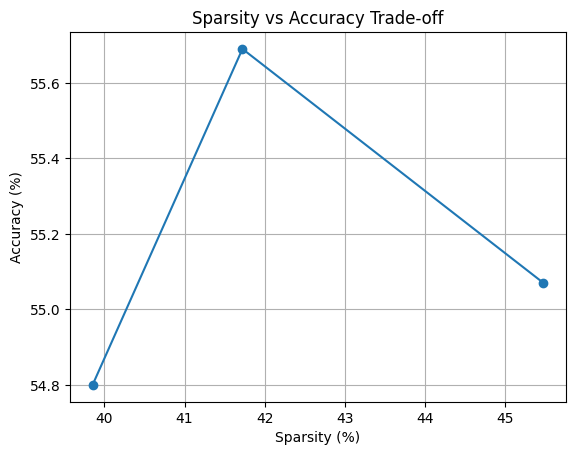

In [17]:
plt.figure()
plt.plot(sparsities, accuracies, marker='o')
plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Sparsity vs Accuracy Trade-off")
plt.grid()
plt.show()

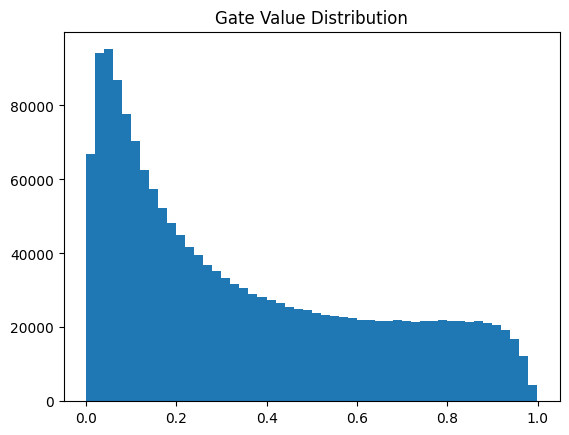

In [18]:
best_model = models[np.argmax(accuracies)]

gates = torch.cat([
    torch.sigmoid(10 * best_model.fc1.gate_scores).flatten(),
    torch.sigmoid(10 * best_model.fc2.gate_scores).flatten(),
    torch.sigmoid(10 * best_model.fc3.gate_scores).flatten()
]).cpu().detach().numpy()

plt.figure()
plt.hist(gates, bins=50)
plt.title("Gate Value Distribution")
plt.show()